# PRODIGY InfoTech Data Science Internship

## Task 01: Data Visualization using Spotify Tracks Dataset

### Objective
This project aims to visualize categorical and numerical variables from the Spotify Tracks dataset using Python. It analyzes song popularity, genres, artists, and explicit content to uncover meaningful insights through data visualization.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [68]:
df = pd.read_csv("spotify_tracks.csv")

In [69]:
df.head()

,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,acoustic,The Goo Goo Dolls,Dizzy up the Girl,46,116573,False
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,acoustic,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),33,133922,False


### Observation

The dataset contains information about Spotify tracks including their names, genres, artists, popularity, duration, and explicit content. The first five records confirm that the dataset has been loaded successfully.

In [70]:
df.shape

(6300, 8)

### Observation

The dataset contains 6300 rows and 8 columns, which is enough data to visualize and analyze.

In [71]:
df.columns

Index(['id', 'name', 'genre', 'artists', 'album', 'popularity', 'duration_ms',
       'explicit'],
      dtype='object')

### Observation

The dataset consists of eight attributes:

- ID
- Song Name
- Genre
- Artist
- Album
- Popularity
- Duration
- Explicit Content

These features include both categorical and numerical variables suitable for visualization.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           6300 non-null   object
 1   name         6300 non-null   object
 2   genre        6300 non-null   object
 3   artists      6300 non-null   object
 4   album        6300 non-null   object
 5   popularity   6300 non-null   int64 
 6   duration_ms  6300 non-null   int64 
 7   explicit     6300 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 350.8+ KB


### Observation

The data set is made up of a combination of object, integer, and boolean data types. There are no missing values in the data set, indicating that the dataset is complete and ready for analysis.

In [73]:
df.describe()

,popularity,duration_ms
count,6300.000000,6.300000e+03
mean,30.754762,2.028477e+05
std,19.948991,1.210299e+05
min,0.000000,3.006000e+04
25%,16.000000,1.476870e+05
50%,29.000000,1.916070e+05
75%,45.000000,2.369625e+05
max,90.000000,3.601658e+06


### Observation

The statistical summary contains data like min, max, quartiles and means of numerical columns like popularity and duration. This assists in understanding the dustribution and variation of the numerical features

In [74]:
df.isnull().sum()

,0
id,0
name,0
genre,0
artists,0
album,0
popularity,0
duration_ms,0
explicit,0


### Observation

There are no missing values in any of the columns. Thus, there is no need for data cleaning with respect to missing values.

In [75]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [76]:
print("Unique Genres :", df["genre"].nunique())
print("Unique Artists :", df["artists"].nunique())
print("Unique Albums :", df["album"].nunique())

Unique Genres : 126
Unique Artists : 4651
Unique Albums : 4949


### Observation

The dataset is diverse in genres, artists and albums, which allows for categorical analysis and visualization.

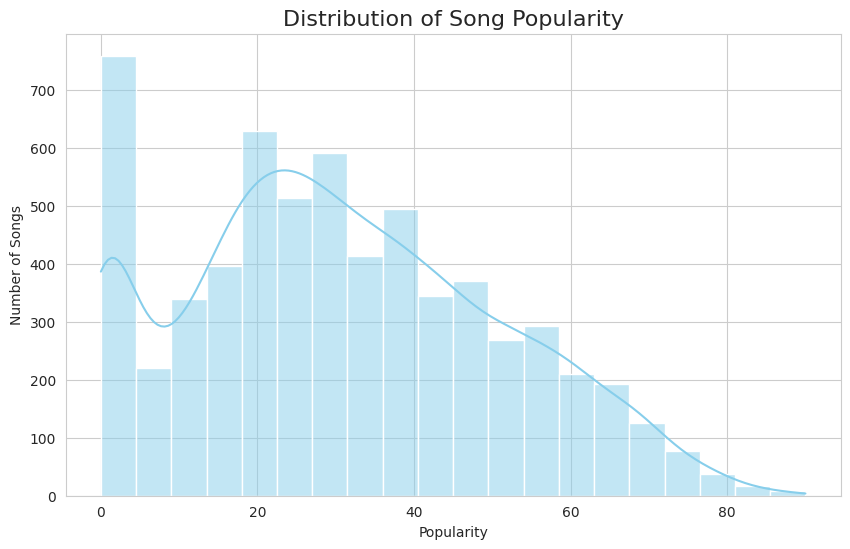

In [77]:
plt.figure(figsize=(10,6))

sns.histplot(df["popularity"],
             bins=20,
             kde=True,
             color="skyblue")

plt.title("Distribution of Song Popularity", fontsize=16)
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

### Observation

The histogram shows the distribution of the song popularity score in the Spotify dataset. The popularity values for most songs range from 15 to 50, with moderately popular songs being more frequent than highly popular songs. This distribution is somewhat skewed, with a few songs scoring very high on popularity.

/tmp/ipykernel_4437/1267434899.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


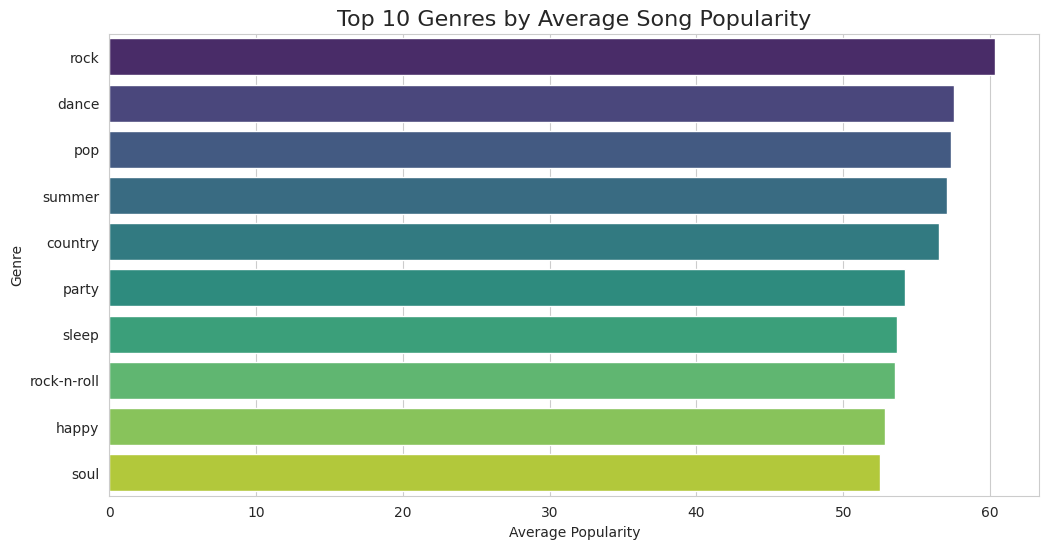

In [78]:
# average popularity for each genre
avg_popularity = (
    df.groupby("genre")["popularity"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)


plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_popularity.values,
    y=avg_popularity.index,
    palette="viridis"
)

plt.title("Top 10 Genres by Average Song Popularity", fontsize=16)
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

### Observation

The following bar chart shows the 10 most popular genres of music with the highest mean popularity of each song. Rock has the highest average popularity score, with Dance and Pop being the second and third respectively. The average popularity scores for Summer, Country and Party are also high. This analysis indicates that there are differences in listener engagement among genres, and that some genres appeal to more listeners consistently than others.

/tmp/ipykernel_4437/725173930.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


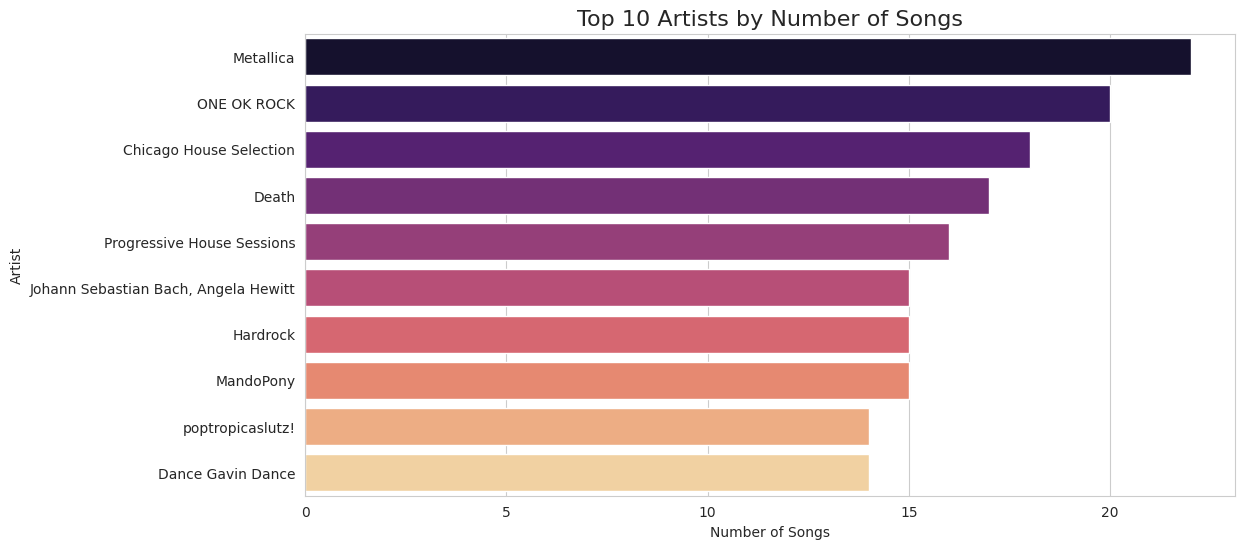

In [79]:
top_artists = df["artists"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index,
    palette="magma"
)

plt.title("Top 10 Artists by Number of Songs", fontsize=16)
plt.xlabel("Number of Songs")
plt.ylabel("Artist")

plt.show()

### Observation

The bar chart displays the top 10 artists that have the largest quantity of songs in the data set. Metallica is the biggest with a few from ONE OK ROCK and Chicago House Selection. The chart shows that a few artists contribute more songs to the dataset than others, with Metallica appearing most frequently.

/tmp/ipykernel_4437/1368922021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


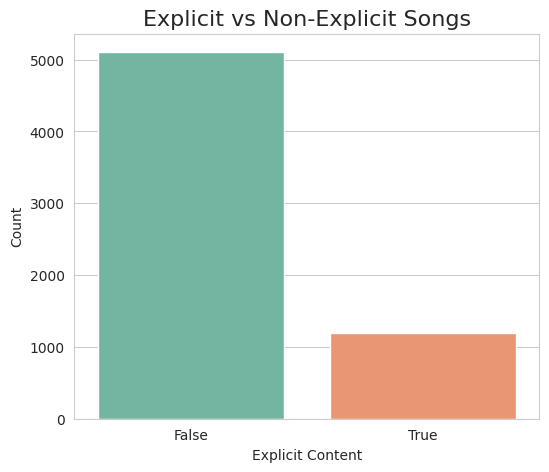

In [80]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="explicit",
    data=df,
    palette="Set2"
)

plt.title("Explicit vs Non-Explicit Songs", fontsize=16)
plt.xlabel("Explicit Content")
plt.ylabel("Count")

plt.show()

### Observation

Most of the songs in the dataset are non-explicit songs and only a small number are explicit.

# Conclusion

The aim of this project was to investigate and visualize the Spotify Tracks dataset using Python libraries like Pandas, Matplotlib, and Seaborn.

Basic exploratory data analysis (EDA) was used to examine the dataset, confirming that there were no missing or duplicate values, and the dataset was suitable to be visualised and analysed.

The visualizations gave us a lot of useful information:

- The popularity distribution indicates that most songs have moderate popularity, while only a few achieve very high popularity.
- Rock, Dance and Pop have some of the highest average song popularity, reflecting higher listener engagement.
- Some artists, like Metallica and ONE OK ROCK, have more songs in the set than other artists.
- Most of the tracks are non-explicit, while there are little explicit songs.

In conclusion, this project showcases the power of data visualization in analyzing real-world data, uncovering patterns, and extracting insights into music trends and listener preferences.